In [ ]:
"""
Main file

This file aims to calculate Activity Count for raw data (csv file) with the agcounts package.

Publication reference of the method:
Neishabouri, A., Nguyen, J., Samuelsson, J., Guthrie, T., Biggs, M., Wyatt, J., Cross, D., Karas, M., Migueles, J. H., Khan, S., & Guo, C. C. (2022).
Quantification of acceleration as activity counts in ActiGraph wearable. Scientific reports, 12(1), 11958. https://doi.org/10.1038/s41598-022-16003-x

Github link containing the package's code:
https://github.com/actigraph/agcounts

"""

Imports

In [1]:
import pandas as pd
import numpy as np
from agcounts.extract import get_counts
import matplotlib.pyplot as plt
import openpyxl
from openpyxl import Workbook
import os

Pre processing (appel d'un autre fichier)

Activity Count Transformation

In [ ]:
def get_counts_csv(
    file,
    freq: int,
    epoch: int,
    fast: bool = True,
    verbose: bool = False,
    time_column: str = None,
):
    if verbose:
        print("Reading in CSV", flush=True)
    raw = pd.read_csv(file, skiprows=0,decimal=",")# skiprows = 0 if the file has no header, skiprows = n if the file has n header rows
    if time_column is not None:
        ts = raw[time_column]
        ts = pd.to_datetime(ts)
        time_freq = str(epoch) + "S"
        ts = ts.dt.round(time_freq)
        ts = ts.unique()
        ts = pd.DataFrame(ts, columns=[time_column])
    raw = raw[["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]].astype(float)
    if verbose:
        print("Converting to array", flush=True)
    raw = np.array(raw)
    if verbose:
        print("Getting Counts", flush=True)
    counts = get_counts(raw, freq=freq, epoch=epoch, fast=fast)
    del raw
    counts = pd.DataFrame(counts, columns=["Axis1", "Axis2", "Axis3"])
    counts["AC"] = (
        counts["Axis1"] ** 2 + counts["Axis2"] ** 2 + counts["Axis3"] ** 2
    ) ** 0.5
    if time_column is not None:
        ts = ts[0 : counts.shape[0]]
        counts = pd.concat([ts, counts], axis=1)
    return counts


def convert_counts_csv(
    file,
    outfile,
    freq: int=100,
    epoch: int=60,
    verbose: bool = False,
    time_column: str = None,
):
    counts = get_counts_csv(
        file, freq=freq, epoch=epoch, verbose=verbose, time_column=time_column
    )
    counts.to_csv(outfile, index=False)
    return counts


dom_counts = get_counts_csv("C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Adele_13h48_15h18.csv", freq=100, epoch=2)
dom_counts = convert_counts_csv(
    "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Adele_13h48_15h18.csv",
    outfile="C:/Users/BEaCHILD3/Documents/Stage_Romane/Fichiers_python/Activity_counts_files/dom_counts.csv",
    freq=100,
    epoch=1,
    verbose=True,
    time_column="Timestamp",
)

non_dom_counts = get_counts_csv("C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Adele_13h48_15h18.csv", freq=100, epoch=2)
non_dom_counts = convert_counts_csv(
    "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Adele_13h48_15h18.csv",
    outfile="C:/Users/BEaCHILD3/Documents/Stage_Romane/Fichiers_python/Activity_counts_files/non_dom_counts.csv",
    freq=100,
    epoch=1,
    verbose=True,
    time_column="Timestamp",
)

dom_AC = dom_counts["AC"]
non_dom_AC = non_dom_counts["AC"]


Reading in CSV
Converting to array
Getting Counts


C:\Users\BEaCHILD3\AppData\Local\Temp\ipykernel_2552\1244303189.py:16: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  ts = ts.dt.round(time_freq)


Reading in CSV
Converting to array
Getting Counts


C:\Users\BEaCHILD3\AppData\Local\Temp\ipykernel_2552\1244303189.py:16: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  ts = ts.dt.round(time_freq)


<class 'pandas.core.series.Series'>


Metrics : 1s calculation

In [3]:
#Array to contain the metrics per seconds
magnitude_ratio = []
bilateral_magnitude = []

for idx_sec in range(len(dom_AC)):

    #Magnitude Ratio 
    #*******Calcul de Bailey RR 2014 : +1 pour chaque AC pour ne pas diviser par 0**********
    if (non_dom_AC[idx_sec] != 0) & (dom_AC[idx_sec] != 0) :
        magnitude_ratio.append(np.log((non_dom_AC[idx_sec] + 1) / (dom_AC[idx_sec] + 1)))

 
    """
    #Magnitude ratio
    #*******Calculs de Lang 2017********
    if (non_dom_AC[idx_sec] != 0) & (dom_AC[idx_sec] != 0) :
        MR_sec = np.log(non_dom_AC[idx_sec]/dom_AC[idx_sec])
        if MR_sec > 7:
            MR_sec = 7
        elif MR_sec < -7:
            MR_sec = -7
        magnitude_ratio.append(MR_sec)
    """


    #Bilateral magnitude 
    bilateral_magnitude.append(non_dom_AC[idx_sec] + dom_AC[idx_sec])

print(np.mean(magnitude_ratio))


-0.7113753830833077


MAUI and BAUI

In [4]:
"""*************************************************************************** FORMULES OKAY ********************************************************************************************"""
#Initializations
dom_MAUI = []
non_dom_MAUI = []
dom_BAUI = []
non_dom_BAUI = []

for idx_sec in range(len(dom_AC)):
    #MAUI
    #Dominant mouvement intensities when non dominant arm is not moving
    if (non_dom_AC[idx_sec] == 0) & (dom_AC[idx_sec] != 0) :
        dom_MAUI.append(dom_AC[idx_sec])
    #Non dominant mouvement intensities when dominant arm is not moving
    elif (non_dom_AC[idx_sec] != 0) & (dom_AC[idx_sec] == 0) :
        non_dom_MAUI.append(non_dom_AC[idx_sec])

    #BAUI
    #Dominant and non dominant mouvement intensities when the other UL is also moving
    if (non_dom_AC[idx_sec] != 0) & (dom_AC[idx_sec] != 0) :
        dom_BAUI.append(dom_AC[idx_sec])
        non_dom_BAUI.append(non_dom_AC[idx_sec])

#MAUI = sum(non dominant mvt when dominant UL is not moving) / sum(dominant mvt when non dominant UL is not moving)
maui = np.sum(non_dom_MAUI) / np.sum(dom_MAUI)
print(f" MAUI : {maui}")

#BAUI = sum(non dominant mvt when dominant UL is also moving) / sum(dominant mvt when non dominant UL is also moving)
baui = np.sum(non_dom_BAUI) / np.sum(dom_BAUI)
print(f" BAUI : {baui}")

 MAUI : 0.18939106618157728
 BAUI : 0.5472328541298093


Metrics : mean calculation and standard deviation

In [5]:
"""**************************CHANGER LES PRINTS PAR DES ENREGISTREMENTS DANS UN FICHIER EXCEL********************************************"""

"""*************************************************************************** FORMULES OKAY ********************************************************************************************"""

#Calculate Active Counts (AC) per 2 seconds epoch (to satisfy threshold of 75.0)
two_sec_dom_AC = []
two_sec_non_dom_AC = []

for idx_sec in range(0,len(dom_AC),2):
    two_sec_dom_AC.append(dom_AC[idx_sec] + dom_AC[idx_sec+1])
two_sec_dom_AC = np.array(two_sec_dom_AC)
for idx_sec in range(0,len(non_dom_AC),2):
    two_sec_non_dom_AC.append(non_dom_AC[idx_sec] + non_dom_AC[idx_sec+1])
two_sec_non_dom_AC = np.array(two_sec_non_dom_AC)

#Active duration
dom_AD = np.sum(two_sec_dom_AC > 75.0) *100 / len(two_sec_dom_AC) 
non_dom_AD = np.sum(two_sec_non_dom_AC > 75.0) *100 / len(two_sec_non_dom_AC) 
print(f"Dominant Active Duration : {dom_AD} % ")
print(f"Non dominant Active Duration : {non_dom_AD} %")
#Std
#std_dom_AD = np.std(dom_counts["AC"] > 75.0) 
#std_non_dom_AD = np.std(non_dom_counts["AC"] > 75.0)
#print(f"Dominant Active Duration standard deviation : {std_dom_AD}")
#print(f"Non dominant Active Duration standard deviation : {std_non_dom_AD}\n")


#Use ratio with Active Duration
use_ratio_time = non_dom_AD / dom_AD
print(f"Use ratio : {use_ratio_time}")
#Std
#std_use_ratio_time = np.std(use_ratio_time)
#print(f"Use ratio standard deviation: {std_use_ratio_time}\n")


#Mean AC 
dom_mean_AC = np.mean(dom_AC)
non_dom_mean_AC = np.mean(non_dom_AC) 
print(f"Dominant mean Activity Counts per sec: {dom_mean_AC}")
print(f"Non dominant mean Activity Counts per sec : {non_dom_mean_AC}")
#Std AC
#std_dom_AC = np.std(dom_AC)
#std_non_dom_AC = np.std(non_dom_AC)
#print(f"Dominant AC standard deviation per sec : {std_dom_AC}")
#print(f"Non dominant AC standard deviation per sec : {std_non_dom_AC}\n")


#Mean Bilateral Magnitude
mean_bilateral_magnitude = np.mean(bilateral_magnitude)
print(f"Mean Bilateral Magnitude : {mean_bilateral_magnitude}")
#Std
#std_bilateral_magnitude = np.std(bilateral_magnitude)
#print(f"Bilateral Magnitude standard deviation : {std_bilateral_magnitude}\n")


#Mean Magnitude Ratio 
mean_magnitude_ratio = np.mean(magnitude_ratio)
print(f"Mean Magnitude Ratio : {mean_magnitude_ratio}")
#Std
#std_magnitude_ratio = np.std(magnitude_ratio)
#print(f"Mean Magnitude Ratio : {std_magnitude_ratio} \n")

Dominant Active Duration : 64.51851851851852 % 
Non dominant Active Duration : 41.888888888888886 %
Use ratio : 0.6492537313432836
Dominant mean Activity Counts per sec: 92.40867065990547
Non dominant mean Activity Counts per sec : 46.85880014574167
Mean Bilateral Magnitude : 139.26747080564715
Mean Magnitude Ratio : -0.7113753830833077


Export in excel

1. Loading file

In [6]:
""" ***********************Changer le chemin : soit demande en paramètre d'entrée, soit creer un autre fichier si le nom existe déjà (pour ne pas écraser les données) ******************** """
from openpyxl.styles import PatternFill
from openpyxl.styles import Alignment


file_path = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Fichiers_python/Metrics_outcome.xlsx"

if os.path.exists(file_path): 
    # If file exists, save existing data and add modifications
    my_wb = openpyxl.load_workbook(file_path)  # Save existing data
    my_sheet = my_wb.active

    """*****************************Changer le num de la colonne et le num du Child (dans le nom de la cell), en mettant un paramètre pour le N ieme fichier traité**********************************"""
    # Add a new child in the first row
    cell = my_sheet.cell(row=1, column=3)
    cell.value = "Child 2"

else:
    # Create file 
    my_wb = openpyxl.Workbook()
    my_sheet = my_wb.active

    # Color for the first row : light blue
    fill_color = PatternFill(start_color="ADD8E6", end_color="ADD8E6", fill_type="solid")

    # Initialise the first row
    cell = my_sheet.cell(row=1, column=1)
    cell.value = "Metrics"
    cell.fill = fill_color
    cell = my_sheet.cell(row=1, column=2)
    cell.value = "Child 1"
    cell.fill = fill_color

    # Save the metric names in the 1st column
    lst_name_metrics = ["Dominant Active Duration (%)", "Non Dominant Active Duration (%)", "Use ratio", "Dominant Mean AC", "Non Dominant Mean AC", "Mean Bilateral Magnitude",  "Mean Magnitude ratio", "MAUI", "BAUI"]
    for idx in range(2, len(lst_name_metrics) + 2):
        cell = my_sheet.cell(row=idx, column=1)
        cell.value = lst_name_metrics[idx-2]
        cell.alignment = Alignment(wrapText=True)

2. Write in file

In [7]:
lst_metrics = [dom_AD, non_dom_AD, use_ratio_time, dom_mean_AC, non_dom_mean_AC, mean_bilateral_magnitude, mean_magnitude_ratio, maui, baui]

"""*********************************** Changer de colonne pour chaque nouvel enfant *******************************************"""
"""*********************************** Changer de feuille pour chaque nouveau jour *******************************************"""
for idx in range(2, len(lst_metrics) + 2):
    cell = my_sheet.cell(row=idx, column=2)
    cell.value = lst_metrics[idx-2]

my_wb.save(file_path)

Metrics graphical display

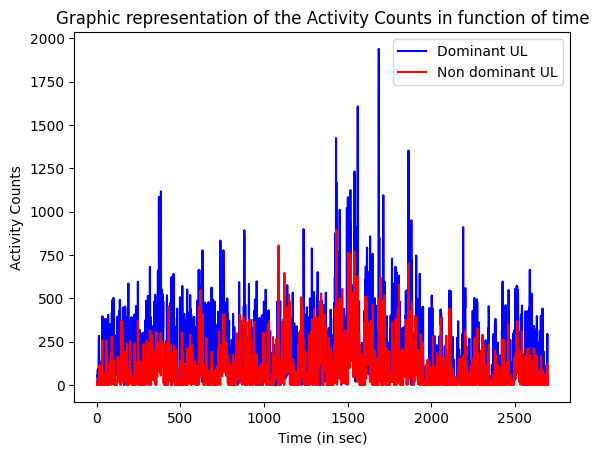

In [4]:
#Axis definition
x_axis_time = np.arange(len(dom_AC))

#Activity Counts per second in function of time
plt.plot(x_axis_time,dom_AC,'b', label = "Dominant UL")
plt.plot(x_axis_time,non_dom_AC,'r', label = "Non dominant UL")


plt.legend()
plt.xlabel("Time (in sec)")
plt.ylabel("Activity Counts")
plt.title(f"Graphic representation of the Activity Counts in function of time")
plt.show()